# Forward market-maximum benchmark

## Purpose and executive summary

This notebook is the **Football-Data reference-price benchmark** for the frozen 2026/27 forward strategy. It evaluates every completed match through the configured inclusive cutoff date that is selected by the published `market_maximum` home-win rule, and assumes that each qualifying bet is fully placed at Football-Data `MaxH`.

The benchmark answers a deliberately narrow question: **how has the frozen signal performed at its reference price?** It does not model whether that price could be captured at a specific venue. Polymarket market discovery, transaction costs, price availability, liquidity, participation, and partial fills belong to the separate collection and execution notebooks 03 and 04.


## 1. Frozen method

For each match, the Football-Data market-maximum price defines

$$
p_{FD} = \frac{1}{MaxH},\qquad
\widehat{G}(p_{FD}) = \widehat{\alpha} + \widehat{\beta}p_{FD},\qquad
\widehat{q}_{FD} = p_{FD} + \widehat{G}(p_{FD}).
$$

A match qualifies only when $p_{FD}$ lies inside its league's probability range frozen after season 2025/26. Parameters and ranges are loaded from the published snapshot; nothing is re-estimated or adapted using 2026/27 outcomes.

Every qualifying settled bet is priced at $O=MaxH$. For stake $S$,

$$
P\&L = \begin{cases} S(MaxH-1), & \text{home win}, \\ -S, & \text{otherwise}. \end{cases}
$$

Fractional Kelly uses only the frozen Football-Data probability,

$$
f^* = \frac{\widehat{q}_{FD}MaxH-1}{MaxH-1},
$$

with the applied fraction capped at 5% per match. For chronological bankroll accounting, stake sizes are fixed at the documented Football-Data release time, and P&L enters the bankroll only after the match. This timing convention prevents unsettled outcomes from affecting later stake sizes, but does not imply that `MaxH` was executable at that exact timestamp.


## 2. Configuration

`ANALYSIS_END_DATE` defines the final match date included in the analysis. The cutoff is inclusive, so matches played on that date are retained and later matches are excluded. This makes it possible to align the benchmark with the observation period covered by the forward execution report.

The staking assumptions are configured below and kept consistent with notebook 04 for comparability. This benchmark assumes full placement at the recorded Football-Data `MaxH`; venue-specific availability, liquidity, and partial execution are evaluated separately in notebooks 03–04.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from datetime import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'pyproject.toml').exists():
        PROJECT_ROOT = candidate
        break

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from football_edge.forward_benchmark import (
    BenchmarkConfig,
    evaluate_benchmark_bets,
    evaluate_benchmark_by_league,
    prepare_benchmark_dataset,
)
from football_edge.forward_execution import (
    order_strategy_rows_for_display,
    round_numeric_for_display,
    separate_common_strategy_statistics,
)
from football_edge.forward_polymarket import prepare_current_season_fixture_selection
from football_edge.plotting import plot_forward_execution_results

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 200)


In [2]:
CURRENT_SEASON_FILE = PROJECT_ROOT / 'data' / 'holdout' / 'all-euro-data-2026-2027.xlsx'
FROZEN_PARAMETERS_FILE = (
    PROJECT_ROOT
    / 'docs'
    / 'parameter_snapshots'
    / 'market_maximum_home_win_asof_2025_26.csv'
)

CURRENT_SEASON = '26_27'
ANALYSIS_END_DATE = '2026-09-30'  # Inclusive.
MARKET_OUTCOME = 'home_win'
ODDS_SOURCE = 'market_maximum'
FIXTURE_TIMEZONE = 'Europe/London'
WEEKEND_RELEASE_TIME_UK = time(17, 0)
MIDWEEK_RELEASE_TIME_UK = time(13, 0)

BENCHMARK_CONFIG = BenchmarkConfig(
    initial_capital_usd=100_000.0,
    flat_stake_usd=1_000.0,
    kelly_fractions=(0.10, 0.25),
    maximum_kelly_stake_fraction=0.05,
    assumed_match_duration_hours=2.0,
    reporting_timezone='Europe/London',
    weekly_frequency='W-MON',  # Tuesday-Monday weeks
    monthly_frequency='M',
    weekly_risk_free_rate=0.0,
)

print('Market-maximum benchmark configuration:')
display(pd.DataFrame([asdict(BENCHMARK_CONFIG)]))
print(f'Analysis end date (inclusive): {ANALYSIS_END_DATE}')


Market-maximum benchmark configuration:


,initial_capital_usd,flat_stake_usd,kelly_fractions,maximum_kelly_stake_fraction,assumed_match_duration_hours,reporting_timezone,weekly_frequency,monthly_frequency,weekly_risk_free_rate
0,100000.0,1000.0,"(0.1, 0.25)",0.05,2.0,Europe/London,W-MON,M,0.0


Analysis end date (inclusive): 2026-09-30


## 3. Current-season data and frozen parameters

The workbook is read directly, and matches are retained only through `ANALYSIS_END_DATE`. Only leagues present in the frozen snapshot are evaluated. Missing odds and unresolved outcomes remain visible in the coverage audit rather than being silently treated as bets.


In [3]:
selection = prepare_current_season_fixture_selection(
    CURRENT_SEASON_FILE,
    FROZEN_PARAMETERS_FILE,
    season=CURRENT_SEASON,
    fixture_timezone=FIXTURE_TIMEZONE,
    weekend_release_time=WEEKEND_RELEASE_TIME_UK,
    midweek_release_time=MIDWEEK_RELEASE_TIME_UK,
    market_outcome=MARKET_OUTCOME,
    source=ODDS_SOURCE,
)
benchmark_data = prepare_benchmark_dataset(
    selection,
    analysis_end_date=ANALYSIS_END_DATE,
)

snapshot_metadata = ['as_of_training_end_season', 'market_outcome', 'source']
print('Frozen parameter snapshot:')
for column in snapshot_metadata:
    values = selection.frozen_parameters[column].dropna().astype(str).drop_duplicates()
    print(f"  {column}: {', '.join(values)}")
display(
    round_numeric_for_display(
        selection.frozen_parameters.drop(columns=snapshot_metadata)
        .sort_values('league', kind='stable')
        .reset_index(drop=True),
        decimals=6,
    )
)


Frozen parameter snapshot:
  as_of_training_end_season: 25_26
  market_outcome: home_win
  source: market_maximum


,league,alpha,beta,accepted_probability_min,accepted_probability_max,accepted_odds_min,accepted_odds_max
0,Greek Super League,-0.042914,0.087709,0.675,0.99,1.01,1.481
1,La Liga,-0.014866,0.055447,0.454,0.99,1.01,2.203
2,Primeira Liga,-0.046892,0.102088,0.595,0.99,1.01,1.681
3,Serie A,-0.038014,0.073193,0.820,0.99,1.01,1.220


## 4. Coverage and match-selection audit

The coverage funnel distinguishes workbook rows, completed matches, usable `MaxH` observations, frozen-rule selections, and settled qualifying bets. The detailed table then shows every match that qualified under the frozen rule; unresolved qualifiers, if any, remain visible but are not settled as benchmark bets. Selection depends only on `MaxH` and frozen parameters, while result columns are retained solely for settlement and audit.


In [4]:
display(benchmark_data.coverage)

audit_display = benchmark_data.audit.rename(
    columns={'football_data_max_home_odds': 'MaxH'}
).sort_values(['match_date', 'league', 'home_team'], kind='stable')
qualifying_audit = audit_display.loc[audit_display['qualifies_frozen_rule']].copy()
display(round_numeric_for_display(qualifying_audit, decimals=4))


,league,matches_loaded,completed_matches,valid_maxh_matches,qualifying_matches,settled_qualifying_bets,missing_or_invalid_maxh,unresolved_matches,unresolved_qualifying_matches
0,All frozen leagues,216,216,216,50,50,0,0,0
1,Greek Super League,35,35,35,7,7,0,0,0
2,La Liga,69,69,69,30,30,0,0,0
3,Primeira Liga,62,62,62,13,13,0,0,0
4,Serie A,50,50,50,0,0,0,0,0


,match_date,league,home_team,away_team,MaxH,p_fd,g_hat_fd,q_hat_fd,accepted_probability_min,accepted_probability_max,home_goals,away_goals,home_win_result,completed_match,valid_maxh,qualifies_frozen_rule,included_benchmark_bet
108,2026-08-09,Primeira Liga,Benfica,Academico Viseu,1.13,0.8850,0.0435,0.9284,0.595,0.99,2,2,0.0,True,True,True,True
111,2026-08-09,Primeira Liga,Porto,Alverca,1.20,0.8333,0.0382,0.8715,0.595,0.99,2,0,1.0,True,True,True,True
113,2026-08-14,Primeira Liga,Sp Lisbon,Guimaraes,1.35,0.7407,0.0287,0.7695,0.595,0.99,3,2,1.0,True,True,True,True
37,2026-08-16,La Liga,Espanol,Levante,2.10,0.4762,0.0115,0.4877,0.454,0.99,3,0,1.0,True,True,True,True
40,2026-08-19,La Liga,Ath Madrid,Malaga,1.33,0.7519,0.0268,0.7787,0.454,0.99,2,0,1.0,True,True,True,True
42,2026-08-21,La Liga,Betis,Sociedad,2.12,0.4717,0.0113,0.4830,0.454,0.99,1,0,1.0,True,True,True,True
0,2026-08-22,Greek Super League,AEK,Iraklis,1.21,0.8264,0.0296,0.8560,0.675,0.99,4,0,1.0,True,True,True,True
2,2026-08-22,Greek Super League,Olympiakos,Atromitos,1.26,0.7937,0.0267,0.8203,0.675,0.99,1,0,1.0,True,True,True,True
43,2026-08-22,La Liga,Ath Bilbao,Sevilla,1.73,0.5780,0.0172,0.5952,0.454,0.99,1,3,0.0,True,True,True,True
123,2026-08-22,Primeira Liga,Sp Lisbon,Alverca,1.24,0.8065,0.0354,0.8419,0.595,0.99,3,1,1.0,True,True,True,True


## 5. Combined benchmark results

All frozen leagues are treated as one portfolio. **Bankroll return** measures the change in portfolio capital. **Stake ROI** measures profit per dollar wagered:

$$
\text{Stake ROI} = 100\times\frac{\sum_i \text{profit}_i}{\sum_i \text{stake}_i}.
$$

Weekly Tuesday-Monday bankroll returns are used for volatility and Sharpe; monthly values are used for presentation. These are complementary measures and should not be interpreted interchangeably.


In [5]:
portfolio_evaluation = evaluate_benchmark_bets(
    benchmark_data.bets,
    config=BENCHMARK_CONFIG,
)

metric_columns = [
    'strategy',
    'cumulative_return_pct',
    'stake_roi_pct',
    'max_drawdown_pct',
    'annualized_weekly_sharpe',
    'annualized_weekly_volatility_pct',
    'mean_weekly_return_pct',
    'weeks_observed',
    'total_stake_usd',
    'profit_usd',
    'final_bankroll_usd',
]
if portfolio_evaluation.metrics.empty:
    print('No completed frozen-rule benchmark bets are currently available.')
else:
    common_sample, strategy_metrics = separate_common_strategy_statistics(
        portfolio_evaluation.metrics
    )
    portfolio_metric_columns = metric_columns.copy()
    if not common_sample.empty:
        print('Common qualifying sample across all strategies:')
        display(round_numeric_for_display(common_sample, decimals=4))
    else:
        portfolio_metric_columns[1:1] = ['bets', 'wins', 'hit_rate_pct']
    strategy_metrics = order_strategy_rows_for_display(strategy_metrics)
    display(round_numeric_for_display(strategy_metrics[portfolio_metric_columns], decimals=4))

    monthly_display = order_strategy_rows_for_display(
        portfolio_evaluation.monthly_returns, group_columns=('month',)
    )
    display(round_numeric_for_display(monthly_display, decimals=4))


Common qualifying sample across all strategies:


,bets,wins,hit_rate_pct
0,50,32,64.0


,strategy,cumulative_return_pct,stake_roi_pct,max_drawdown_pct,annualized_weekly_sharpe,annualized_weekly_volatility_pct,mean_weekly_return_pct,weeks_observed,total_stake_usd,profit_usd,final_bankroll_usd
0,flat stake,-3.5400,-7.0800,6.6426,-1.9977,13.0049,-0.4996,7,50000.0000,-3540.0000,96460.0000
1,10% Kelly,-2.5579,-4.4167,4.1768,-1.3123,13.9973,-0.3532,7,57913.3802,-2557.8657,97442.1343
2,25% Kelly,-4.4357,-3.5898,11.4132,-1.0293,29.1073,-0.5762,7,123562.3625,-4435.6759,95564.3241


,strategy,month,bets,total_stake_usd,profit_usd,stake_roi_pct,start_bankroll_usd,end_bankroll_usd,bankroll_return_pct
0,flat stake,2026-08,22,22000.0000,2670.0000,12.1364,100000.0000,102670.0000,2.6700
1,10% Kelly,2026-08,22,26687.4711,836.6452,3.1350,100000.0000,100836.6452,0.8366
2,25% Kelly,2026-08,22,59371.5248,6076.5229,10.2347,100000.0000,106076.5229,6.0765
3,flat stake,2026-09,28,28000.0000,-6210.0000,-22.1786,102670.0000,96460.0000,-6.0485
4,10% Kelly,2026-09,28,31225.9091,-3394.5109,-10.8708,100836.6452,97442.1343,-3.3663
5,25% Kelly,2026-09,28,64190.8377,-10512.1988,-16.3765,106076.5229,95564.3241,-9.9100


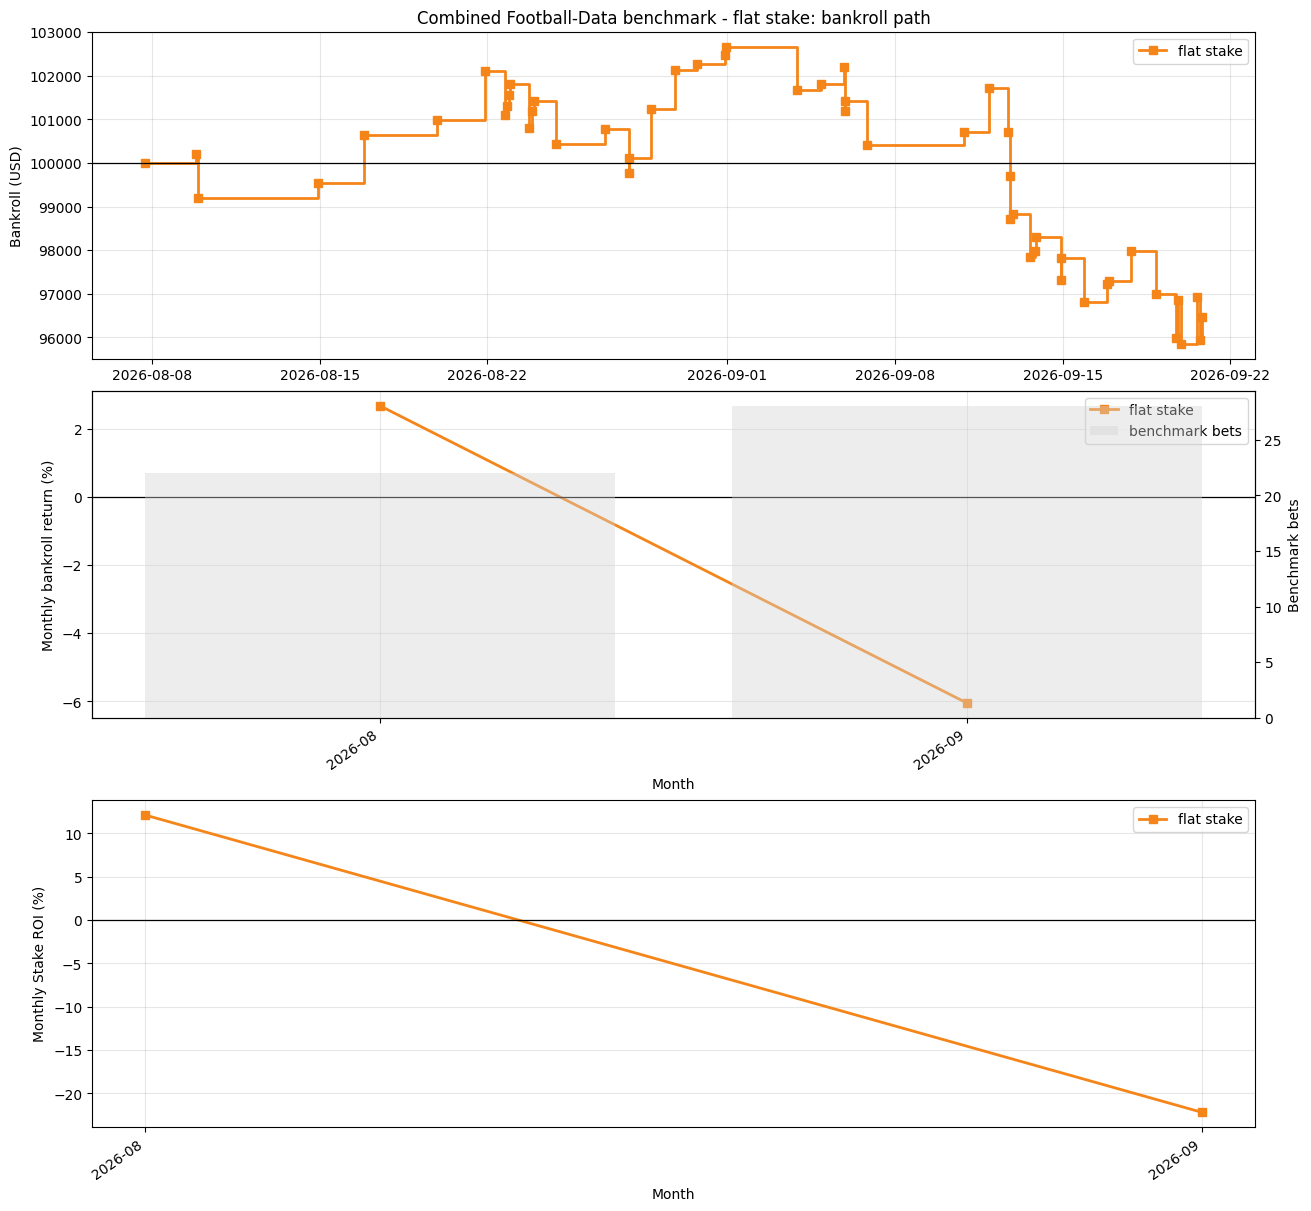

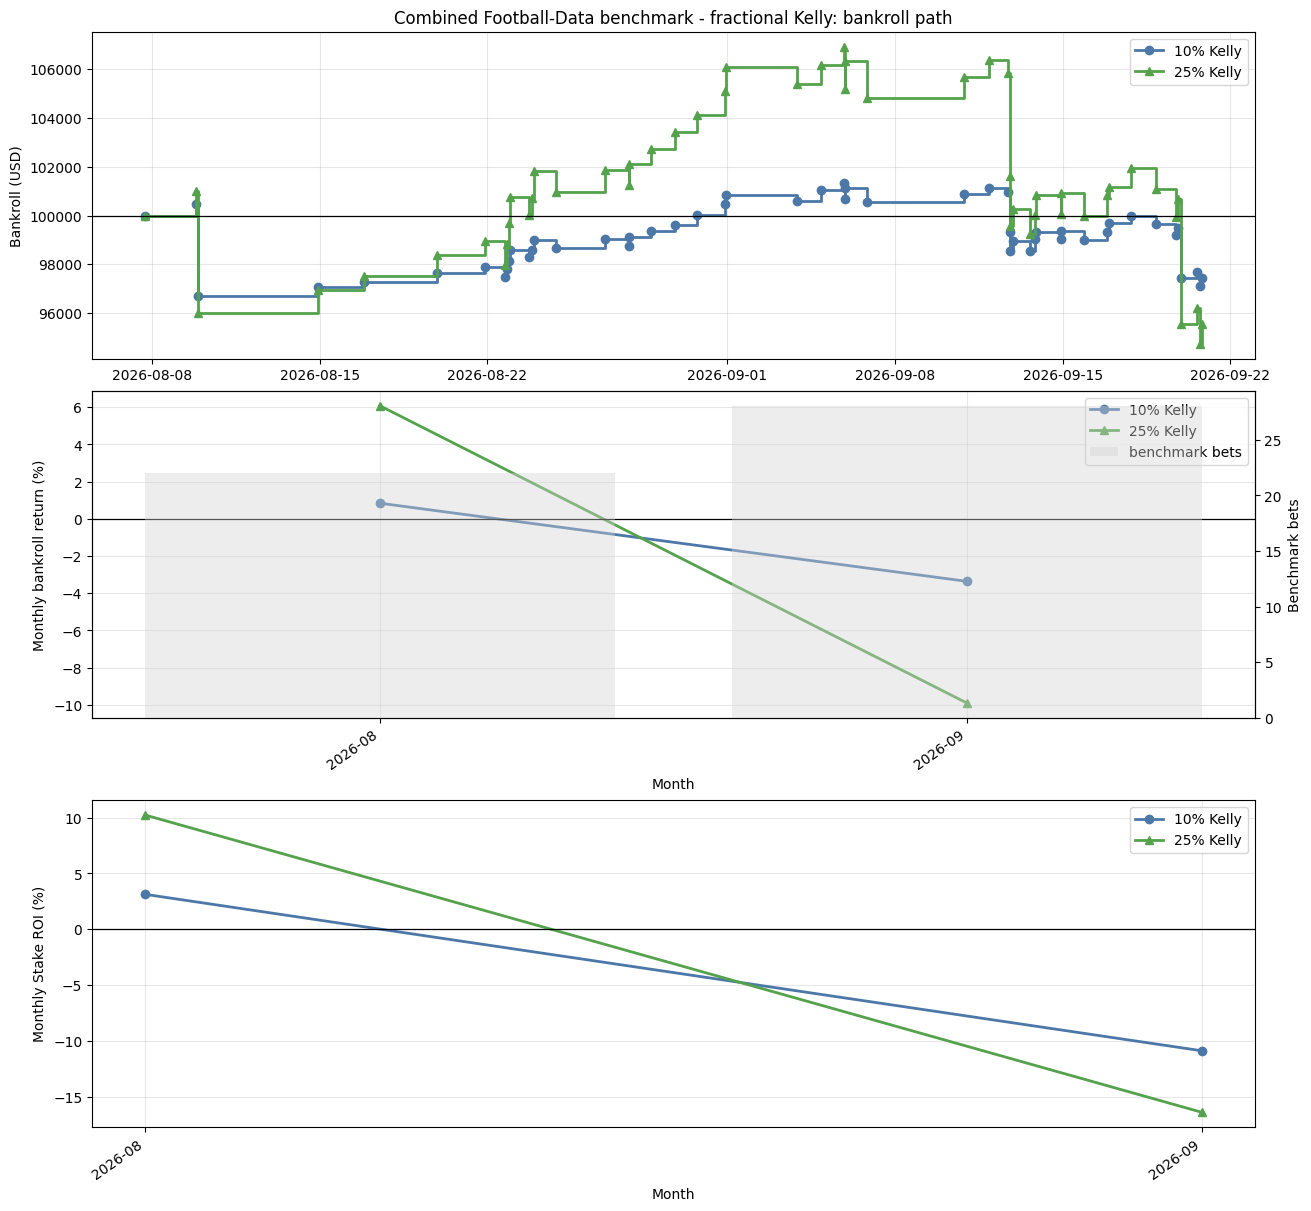

In [6]:
if not portfolio_evaluation.monthly_returns.empty:
    plot_forward_execution_results(
        portfolio_evaluation.simulation.bankroll_paths,
        portfolio_evaluation.monthly_returns,
        strategies=['flat stake'],
        title='Combined Football-Data benchmark - flat stake',
        initial_capital_usd=BENCHMARK_CONFIG.initial_capital_usd,
        reporting_timezone=BENCHMARK_CONFIG.reporting_timezone,
        stake_roi_ylabel='Monthly Stake ROI (%)',
        bets_label='benchmark bets',
    )
    plt.show()

    plot_forward_execution_results(
        portfolio_evaluation.simulation.bankroll_paths,
        portfolio_evaluation.monthly_returns,
        strategies=[f'{fraction:.0%} Kelly' for fraction in BENCHMARK_CONFIG.kelly_fractions],
        title='Combined Football-Data benchmark - fractional Kelly',
        initial_capital_usd=BENCHMARK_CONFIG.initial_capital_usd,
        reporting_timezone=BENCHMARK_CONFIG.reporting_timezone,
        stake_roi_ylabel='Monthly Stake ROI (%)',
        bets_label='benchmark bets',
    )
    plt.show()


## 6. Standalone league sleeves

Each active league is evaluated independently from the same initial capital. These are diagnostic sleeves, not components whose ending capital should be added to the combined portfolio. The same weekly-risk and monthly-presentation conventions are retained.


In [7]:
league_evaluation = evaluate_benchmark_by_league(
    benchmark_data.bets,
    config=BENCHMARK_CONFIG,
)

if league_evaluation.metrics.empty:
    print('No standalone league benchmark results are currently available.')
else:
    league_common, league_metrics = separate_common_strategy_statistics(
        league_evaluation.metrics,
        group_columns=('analysis_league',),
    )
    if not league_common.empty:
        print('Common qualifying samples by league:')
        display(round_numeric_for_display(league_common, decimals=4))
    league_metric_columns = ['analysis_league', *metric_columns]
    if league_common.empty:
        league_metric_columns[2:2] = ['bets', 'wins', 'hit_rate_pct']
    league_metrics = order_strategy_rows_for_display(
        league_metrics, group_columns=('analysis_league',)
    )
    display(round_numeric_for_display(league_metrics[league_metric_columns], decimals=4))


Common qualifying samples by league:


,analysis_league,bets,wins,hit_rate_pct
0,Greek Super League,7,6,85.7143
1,La Liga,30,17,56.6667
2,Primeira Liga,13,9,69.2308


,analysis_league,strategy,cumulative_return_pct,stake_roi_pct,max_drawdown_pct,annualized_weekly_sharpe,annualized_weekly_volatility_pct,mean_weekly_return_pct,weeks_observed,total_stake_usd,profit_usd,final_bankroll_usd
0,Greek Super League,flat stake,0.8400,12.0000,0.9850,2.8741,3.8063,0.2104,4,7000.0000,840.0000,100840.0000
1,Greek Super League,10% Kelly,0.2773,3.3601,1.6070,0.6376,5.8492,0.0717,4,8252.8348,277.3045,100277.3045
2,Greek Super League,25% Kelly,0.6408,3.0708,4.0175,0.6216,14.6719,0.1754,4,20868.6789,640.8254,100640.8254
3,La Liga,flat stake,-2.6200,-8.7333,7.4500,-1.5592,14.1842,-0.4253,6,30000.0000,-2620.0000,97380.0000
4,La Liga,10% Kelly,0.2675,1.0932,2.2800,0.3364,7.5972,0.0491,6,24471.4859,267.5285,100267.5285
5,La Liga,25% Kelly,-0.5135,-1.0400,5.9481,-0.1648,18.4855,-0.0586,6,49378.3174,-513.5294,99486.4706
6,Primeira Liga,flat stake,-1.7600,-13.5385,2.3362,-1.8963,6.8407,-0.2495,7,13000.0000,-1760.0000,98240.0000
7,Primeira Liga,10% Kelly,-3.0963,-12.2857,3.7597,-1.7902,12.6344,-0.4350,7,25202.2174,-3096.2614,96903.7386
8,Primeira Liga,25% Kelly,-4.5875,-8.9791,6.4313,-1.3740,23.5300,-0.6217,7,51090.7412,-4587.5057,95412.4943


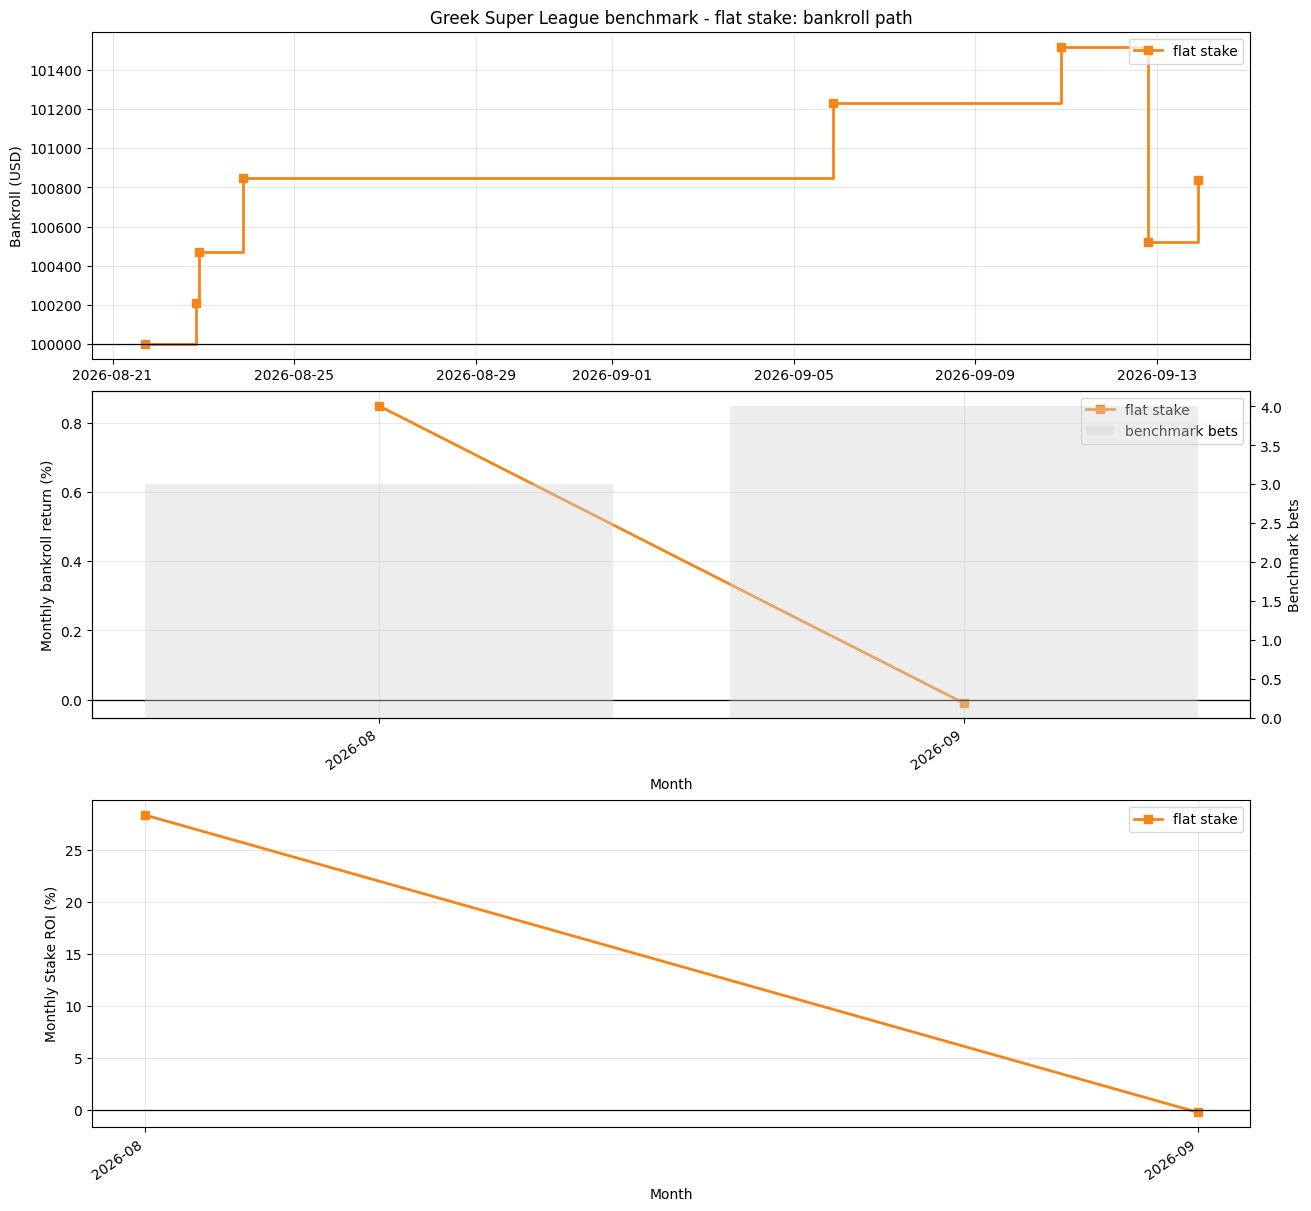

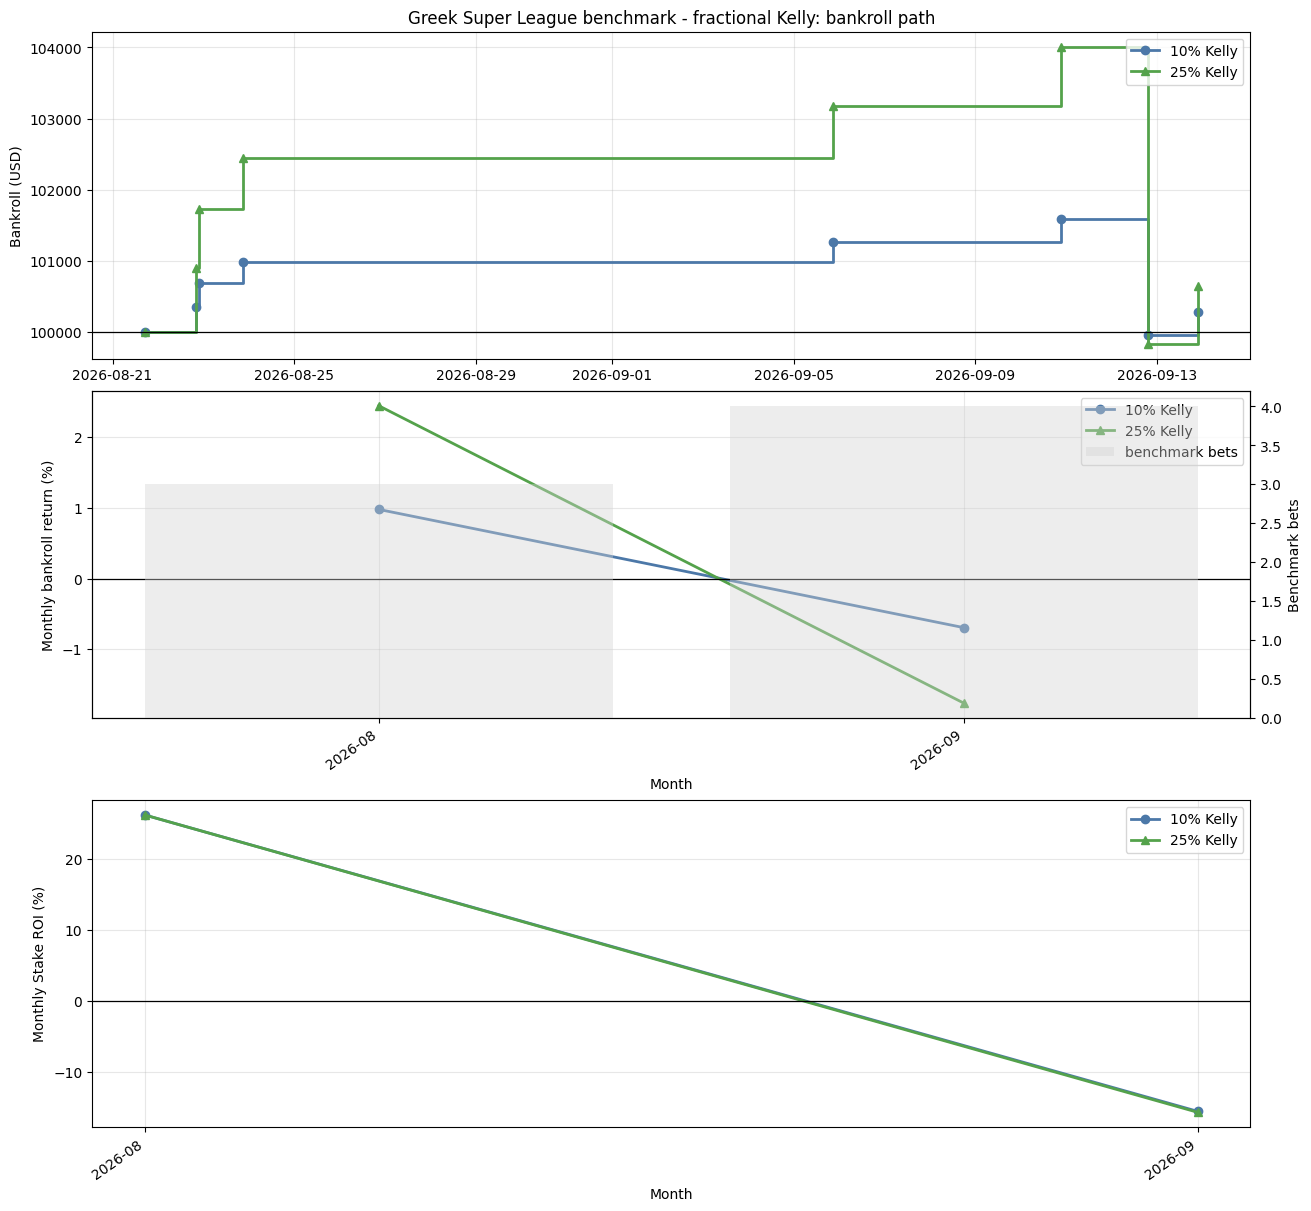

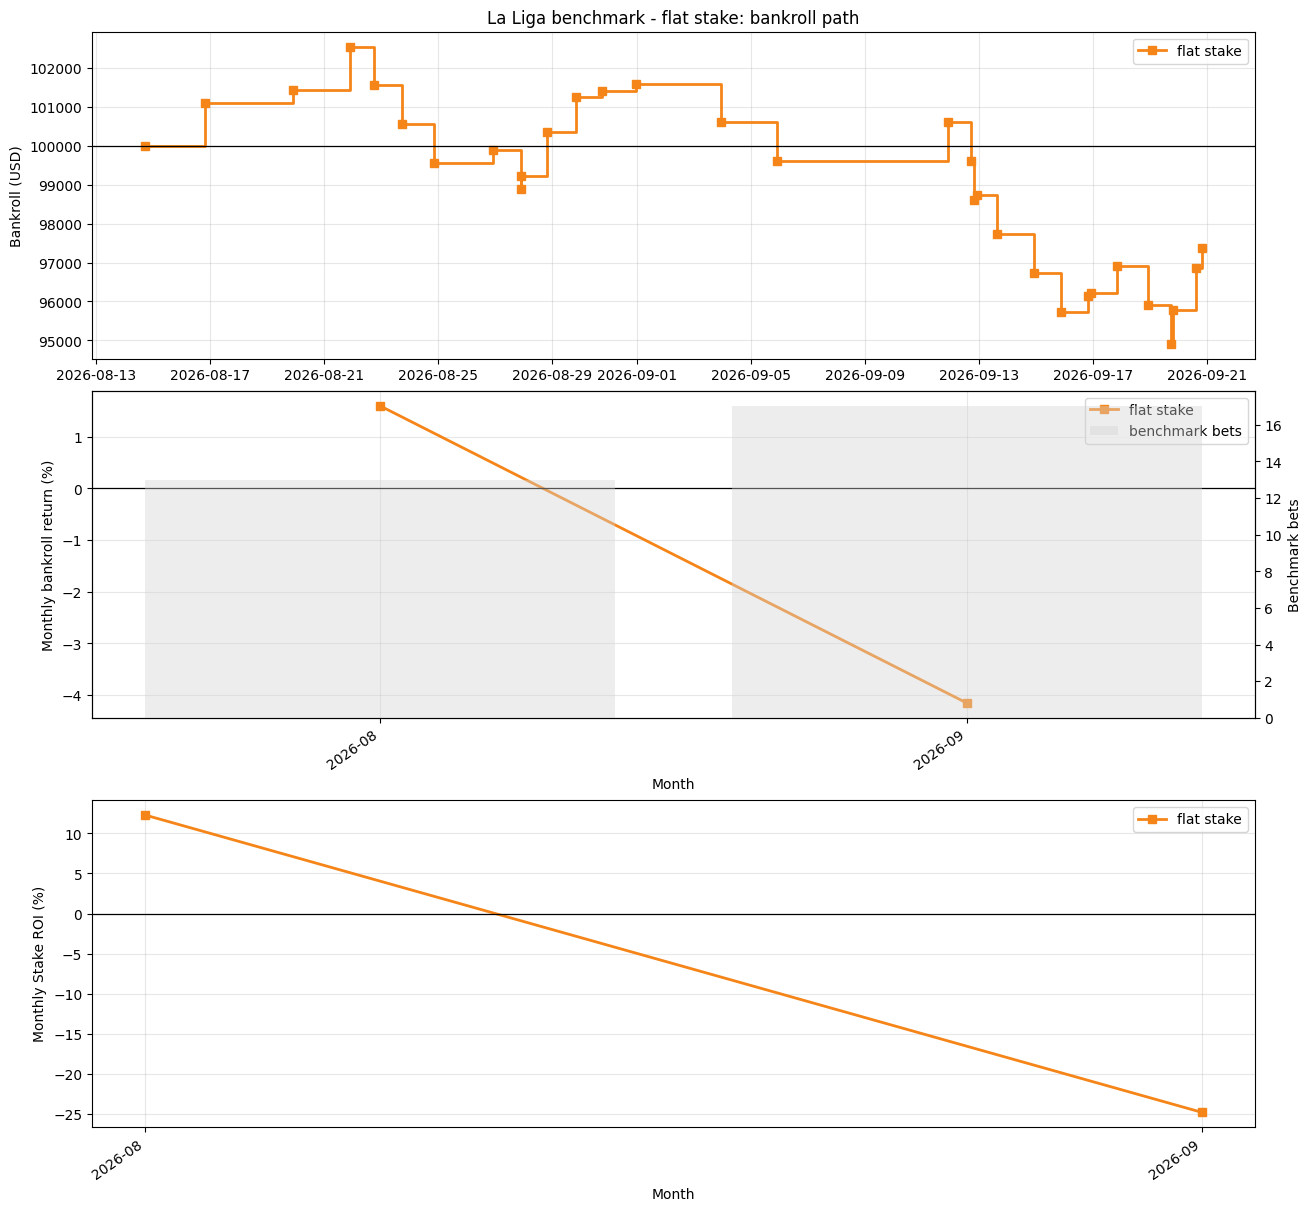

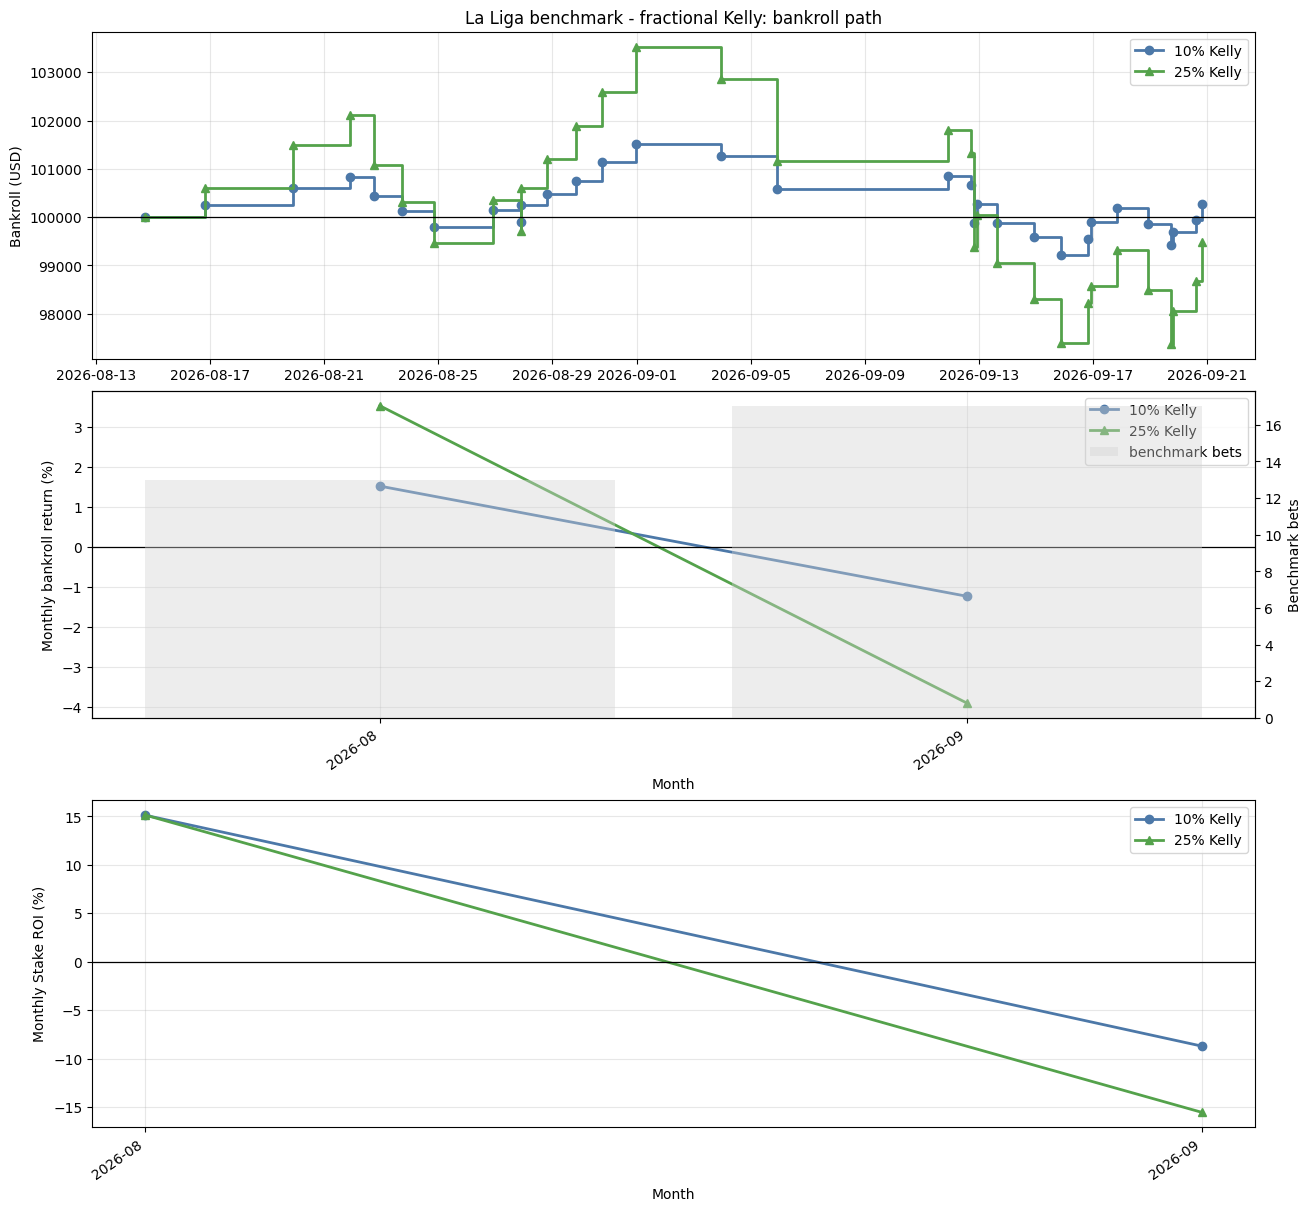

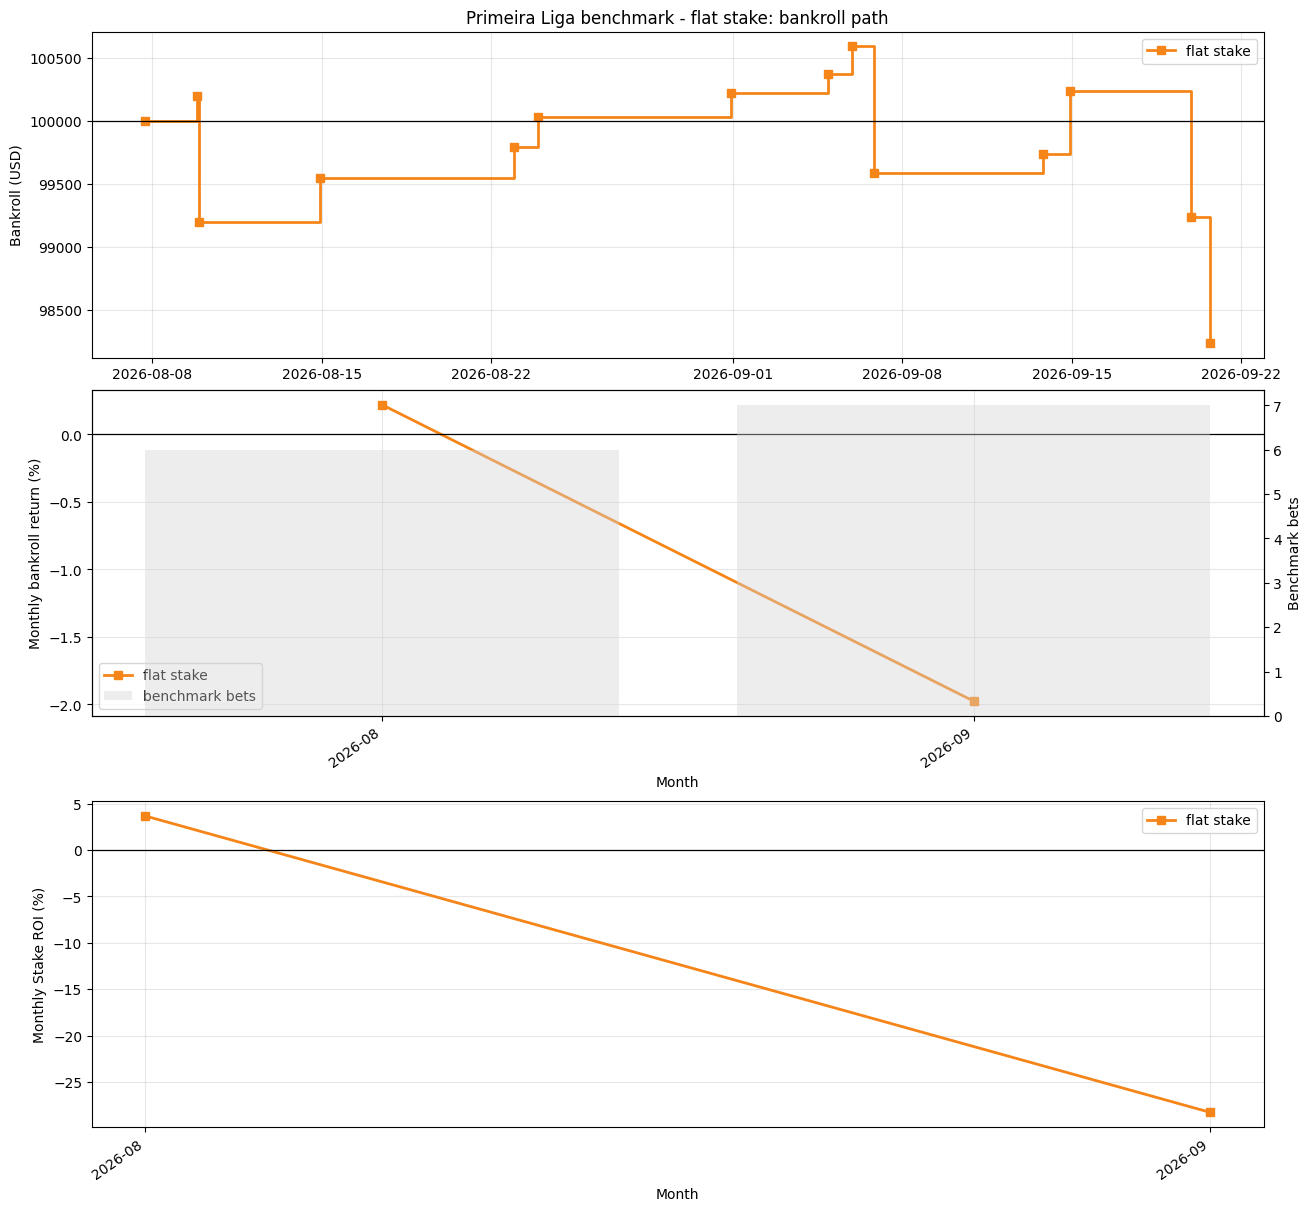

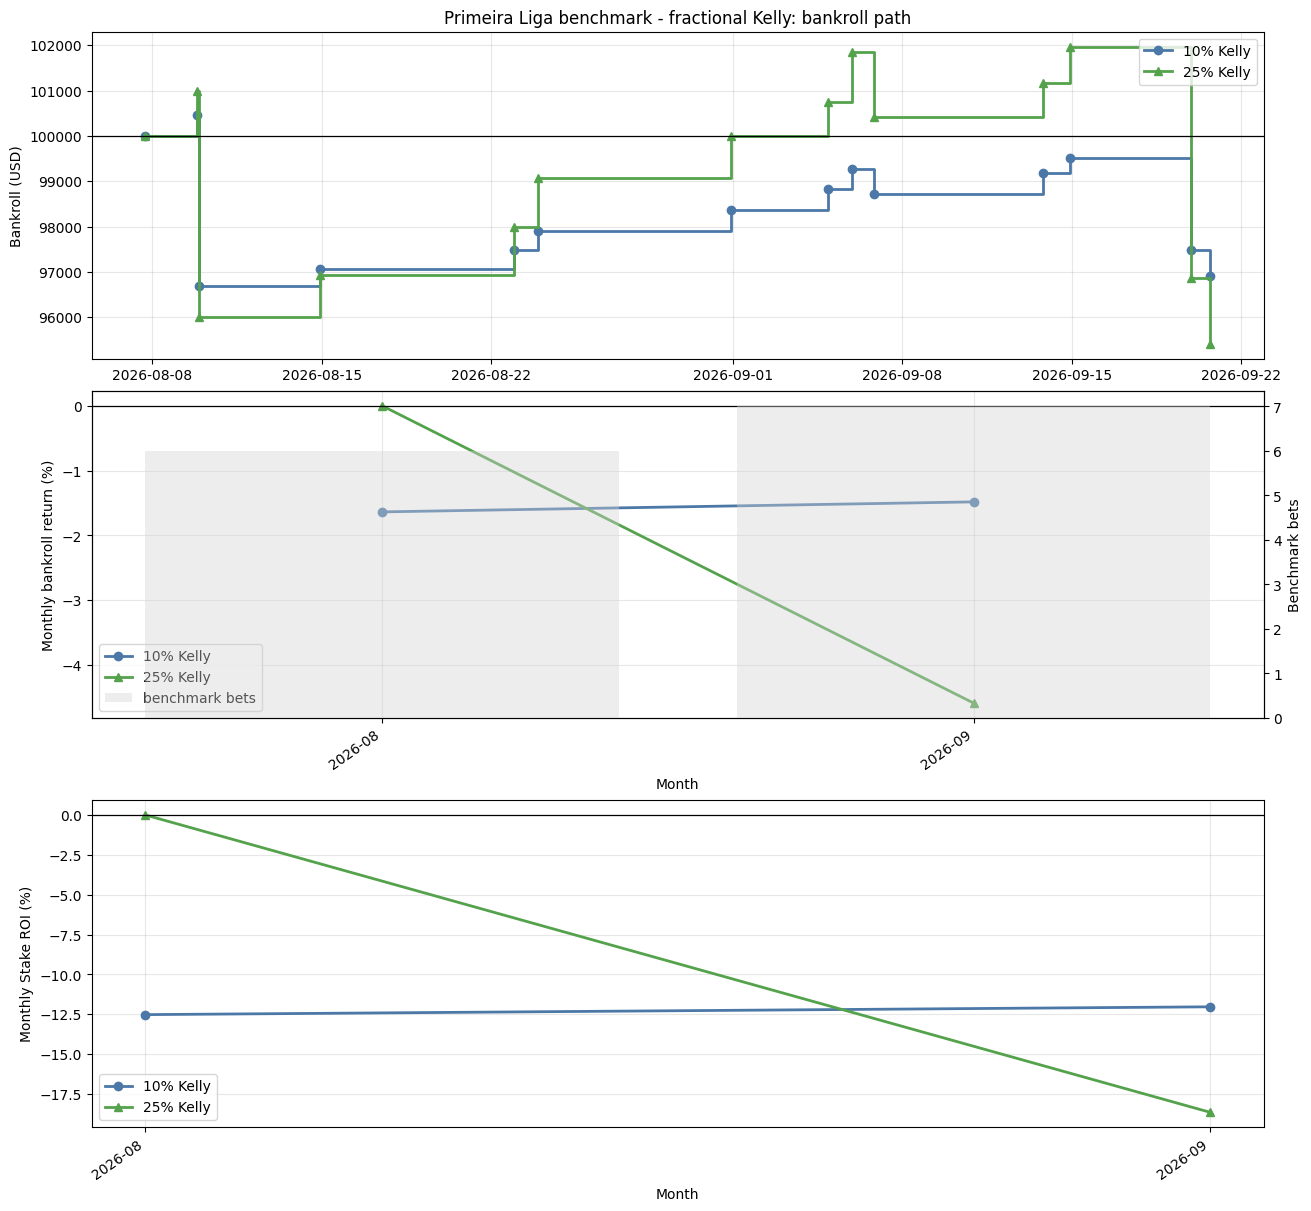

In [8]:
for league in sorted(league_evaluation.metrics.get('analysis_league', pd.Series(dtype=str)).unique()):
    league_paths = league_evaluation.simulation.bankroll_paths.loc[
        league_evaluation.simulation.bankroll_paths['analysis_league'].eq(league)
    ]
    league_monthly = league_evaluation.monthly_returns.loc[
        league_evaluation.monthly_returns['analysis_league'].eq(league)
    ]
    plot_forward_execution_results(
        league_paths,
        league_monthly,
        strategies=['flat stake'],
        title=f'{league} benchmark - flat stake',
        initial_capital_usd=BENCHMARK_CONFIG.initial_capital_usd,
        reporting_timezone=BENCHMARK_CONFIG.reporting_timezone,
        stake_roi_ylabel='Monthly Stake ROI (%)',
        bets_label='benchmark bets',
    )
    plt.show()

    plot_forward_execution_results(
        league_paths,
        league_monthly,
        strategies=[f'{fraction:.0%} Kelly' for fraction in BENCHMARK_CONFIG.kelly_fractions],
        title=f'{league} benchmark - fractional Kelly',
        initial_capital_usd=BENCHMARK_CONFIG.initial_capital_usd,
        reporting_timezone=BENCHMARK_CONFIG.reporting_timezone,
        stake_roi_ylabel='Monthly Stake ROI (%)',
        bets_label='benchmark bets',
    )
    plt.show()


## 7. Interpretation and limitations

The early forward reference-price evidence is mixed. August was profitable across all three staking specifications, but the September losses were large enough to make the combined observation-window return negative for flat stake, 10% Kelly, and 25% Kelly. This is informative prospective evidence rather than a reason to alter the frozen rule: it shows that reference-price signal performance is not uniformly positive month to month and reinforces the value of continuing the forward evaluation. Because the sample is still accumulating, weekly Sharpe, volatility, drawdown, and league-level comparisons should be interpreted as descriptive rather than mature estimates.

The key limitation is execution realism. `market_maximum` is an opportunity-set proxy: the data contains bookmaker-price snapshots but not venue-level timestamps, stake limits, or proof that every maximum quote was simultaneously executable at the desired size. The results should therefore be interpreted as a reference-price signal benchmark rather than direct evidence of executable live capacity. Notebook 03 collects venue-specific Polymarket transactions, while notebook 04 applies explicit cost, price, participation, partial-fill, chronology, and cash constraints. Reading the benchmark and execution results together separates **signal performance** from **execution feasibility**.
